In [79]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import pmdarima.arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

In [80]:
df = pd.read_csv('Impute_misvalues_hungyen.csv')
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,0,47.0
1,1/1/2008,1,43.0
2,1/1/2008,2,40.0
3,1/1/2008,3,37.0
4,1/1/2008,4,34.0


In [81]:
df['Hour'] = df['Hour'].replace('#NUM!', 0)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64061 entries, 0 to 64060
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        64061 non-null  object 
 1   Hour        64061 non-null  object 
 2   Waterlevel  64061 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [83]:
df.describe()

,Waterlevel
count,64061.000000
mean,138.135113
std,97.020489
min,-26.000000
25%,75.000000
50%,116.000000
75%,171.000000
max,651.000000


In [84]:
df.isnull().sum()

Date          0
Hour          0
Waterlevel    0
dtype: int64

In [85]:
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,00:00:00,47.0
1,1/1/2008,01:00:00,43.0
2,1/1/2008,02:00:00,40.0
3,1/1/2008,03:00:00,37.0
4,1/1/2008,04:00:00,34.0


In [86]:
df['Hour'] = df['Hour'].astype(str)


df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'])
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], axis = 1, inplace = True)

df.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,47.0
2008-01-01 01:00:00,43.0
2008-01-01 02:00:00,40.0
2008-01-01 03:00:00,37.0
2008-01-01 04:00:00,34.0


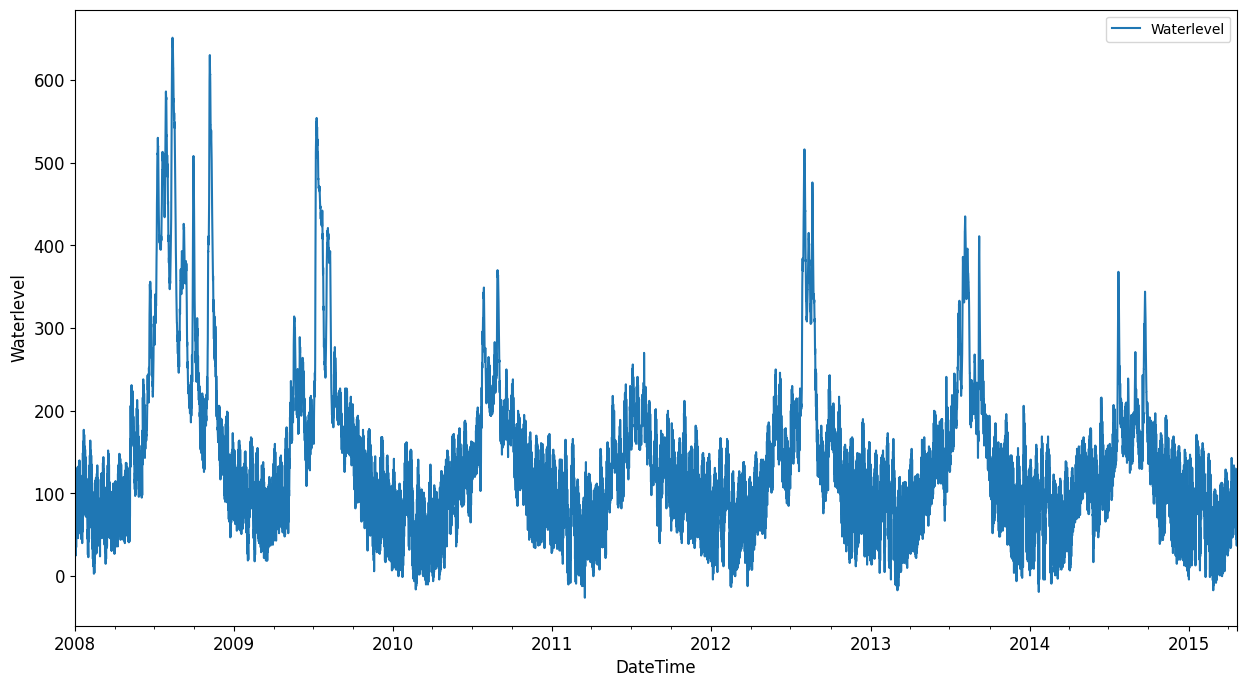

In [87]:
df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()

In [88]:
train_size = int(len(df) * 0.7)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

train, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00        47.0
 2008-01-01 01:00:00        43.0
 2008-01-01 02:00:00        40.0
 2008-01-01 03:00:00        37.0
 2008-01-01 04:00:00        34.0
 ...                         ...
 2013-02-11 05:00:00        86.0
 2013-02-11 06:00:00       100.0
 2013-02-11 07:00:00       115.0
 2013-02-11 08:00:00       128.0
 2013-02-11 09:00:00       134.0
 
 [44842 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-02-11 10:00:00       133.0
 2013-02-11 11:00:00       127.0
 2013-02-11 12:00:00       122.0
 2013-02-11 13:00:00       115.0
 2013-02-11 14:00:00       107.0
 ...                         ...
 2015-04-23 00:00:00       127.0
 2015-04-23 01:00:00       124.0
 2015-04-23 02:00:00       120.0
 2015-04-23 03:00:00       115.0
 2015-04-23 04:00:00       109.0
 
 [19219 rows x 1 columns])

Text(0, 0.5, 'Waterlevel')

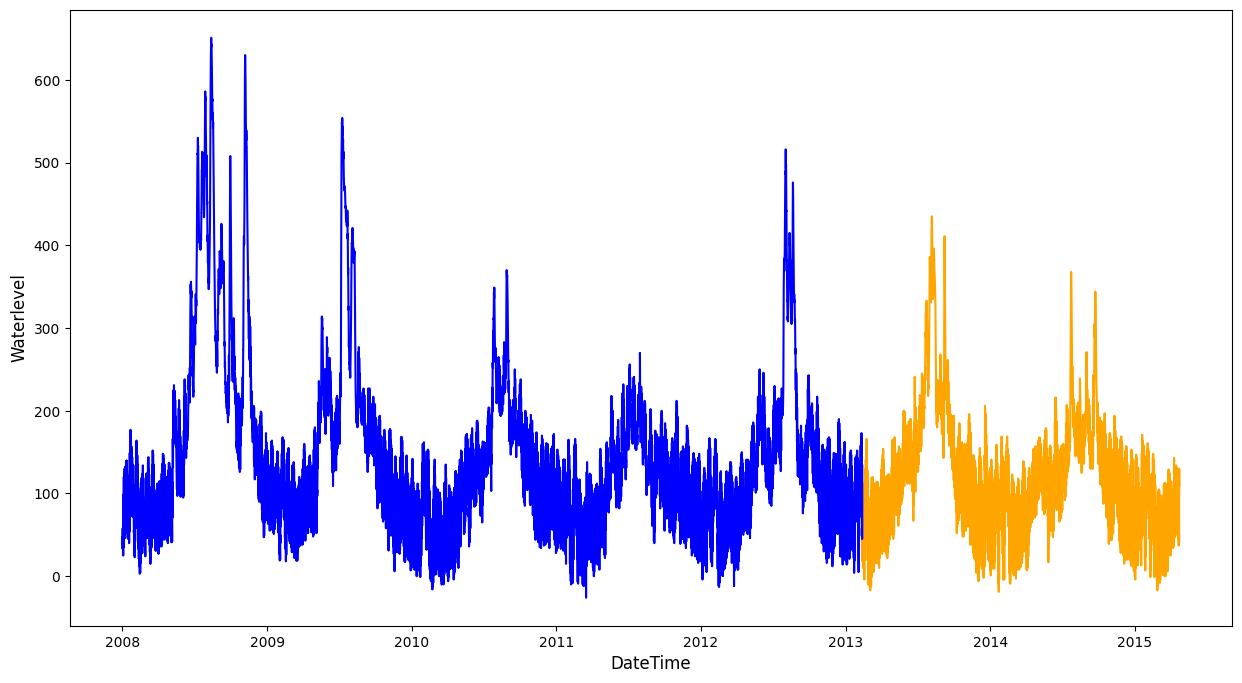

In [89]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Waterlevel'], label = "test", color = 'orange')
plt.plot(train.index, train['Waterlevel'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)

In [90]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)
test['Waterlevel'] = scaler.transform(test)

In [91]:
train_data = train.values
test_data = test.values

In [92]:
timesteps = 268


In [93]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] 
                               for i in range(0,len(train_data)-timesteps+1)])[:,:,0]

test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] 
                              for i in range(0,len(test_data)-timesteps+1)])[:,:,0]


In [94]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

x_train, y_train

(array([[0.10782866, 0.10192024, 0.09748892, ..., 0.14549483, 0.13884786,
         0.12998523],
        [0.10192024, 0.09748892, 0.09305761, ..., 0.13884786, 0.12998523,
         0.12407681],
        [0.09748892, 0.09305761, 0.08862629, ..., 0.12998523, 0.12407681,
         0.1211226 ],
        ...,
        [0.14623338, 0.16248154, 0.183161  , ..., 0.14327917, 0.16543575,
         0.18611521],
        [0.16248154, 0.183161  , 0.19645495, ..., 0.16543575, 0.18611521,
         0.20827179],
        [0.183161  , 0.19645495, 0.20531758, ..., 0.18611521, 0.20827179,
         0.22747415]]),
 array([[0.12407681],
        [0.1211226 ],
        [0.12555391],
        ...,
        [0.20827179],
        [0.22747415],
        [0.23633678]]))

In [95]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    r, _ = pearsonr(y_true, y_pred)
    
    T = len(y_true)
    max_x = max(y_true)
    min_x = min(y_true)
    
    sim_sum = 0
    for i in range(T):
        sim_sum += 1 / (1 + abs(y_pred[i] - y_true[i]) / (max_x - min_x))
    sim = sim_sum / T
    
    sd_y = np.std(y_pred)
    sd_x = np.std(y_test)
    fsd = 2 * np.abs(sd_y - sd_x) / (sd_y + sd_x)
    
    nse = 1 - (np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R': r,
        'SIM': sim,
        'FSD': fsd,
        'NSE': nse
    }

# SVR

In [96]:
model_SVR = SVR(kernel='rbf',gamma=0.01, C=50, epsilon = 0.005)
model_SVR.fit(x_train, y_train[:,0])

In [ ]:
hours = 12
def forecast_value (model, hours):
    current_window = x_train[-1,:].tolist()

    predict = []

    for _ in range(hours):
        next_value = model.predict([current_window])[0]
        predict.append(next_value)
        
        current_window.pop(0)  
        current_window.append(next_value)
    predict_array = np.array(predict).reshape(-1, 1)
    return(predict_array)
predict_SVR = forecast_value(model_SVR, hours)    

In [ ]:
y_test_pred = scaler.inverse_transform(predict_SVR)
y_train_original = scaler.inverse_transform(y_train)
y_test_original = scaler.inverse_transform(test)

print(len(y_test_pred), len(y_train_original), len(y_test_original))

120 44575 19219


In [ ]:
train_timestamps = train.index[timesteps-1:]
test_timestamps = test.index[timesteps-1:]

print(len(train_timestamps), len(test_timestamps))

44575 18952


In [ ]:
metrics_SVR = calculate_metrics(y_test_original[:hours].flatten(), y_test_pred.flatten())
for metric, value in metrics_SVR.items():
    print(f'Using model SVR {metric}: {value}')

Using model SVR MAE: 13.619283621686824
Using model SVR RMSE: 16.6579162480102
Using model SVR R: 0.9076849869523688
Using model SVR SIM: 0.9045935999686923
Using model SVR FSD: 1.9886154633049764
Using model SVR NSE: 0.670192609218411


# KNN

In [ ]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(x_train, y_train[:,0])

KNeighborsRegressor()

In [ ]:
predict_KNN = forecast_value(knn_regressor, hours)

In [ ]:
y_test_pred_knn = scaler.inverse_transform(predict_KNN)

In [ ]:
metrics_KNN = calculate_metrics(y_test_original[:hours].flatten(), y_test_pred_knn.flatten())
for metric, value in metrics_KNN.items():
    print(f'Using model KNN {metric}: {value}')

Using model KNN MAE: 8.876666666666669
Using model KNN RMSE: 11.311668017287873
Using model KNN R: 0.9342571301293947
Using model KNN SIM: 0.9351917836794007
Using model KNN FSD: 1.9863468586727375
Using model KNN NSE: 0.8479199185113951


# RF

In [ ]:
model_RF = RandomForestRegressor(n_estimators=300, max_features=4, random_state=42)

x_train = scaler.inverse_transform(x_train)
y_train = scaler.inverse_transform(y_train)
x_test = scaler.inverse_transform(x_test)
y_test = scaler.inverse_transform(y_test)

model_RF.fit(x_train, y_train[:,0])

RandomForestRegressor(max_features=4, n_estimators=300, random_state=42)

In [ ]:
predict_RF = forecast_value(model_RF, hours)

In [ ]:
metrics_RF = calculate_metrics(y_test_original[:hours].flatten(), predict_RF.flatten())
for metric, value in metrics_RF.items():
    print(f'Using model RF {metric}: {value}')

Using model RF MAE: 15.643861111111109
Using model RF RMSE: 19.53273391785071
Using model RF R: 0.9081832790490733
Using model RF SIM: 0.8931662924950741
Using model RF FSD: 0.9819742715245334
Using model RF NSE: 0.5465336103765416


## ARIMA

In [ ]:
train_ARIMA = scaler.inverse_transform(train_data)
test_ARIMA = scaler.inverse_transform(test_data)
train_ARIMA.shape
test_ARIMA.shape

(19219, 1)

In [ ]:
warnings.filterwarnings(category=UserWarning, action='ignore')
arima_model = pmdarima.arima.auto_arima(train_ARIMA, seasonal=False, 
                                        error_action='ignore', trace=True,
                                        suppress_warnings=True, maxiter=20, stepwise=True,
                                        n_jobs=2)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=200980.726, Time=14.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=289610.714, Time=0.56 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=216400.279, Time=1.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=248451.402, Time=4.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=289608.719, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=207092.816, Time=5.87 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=201845.967, Time=12.83 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=201859.951, Time=15.23 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=200607.340, Time=17.61 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=206436.578, Time=8.62 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=200572.517, Time=18.63 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=200280.772, Time=21.64 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=21.60 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=200378.544, Time=23.94 sec
 ARI

In [ ]:
arima_model.fit(train_ARIMA)

ARIMA(maxiter=20, order=(5, 1, 3), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [ ]:
n_periods = len(test_ARIMA)  # or any integer value you want to use
predictions_arima = arima_model.predict(start = len(train_ARIMA.flatten()),
                                        end = len(test_ARIMA.flatten()),
                                        n_periods = 120)
predictions_arima.shape

(120,)

In [ ]:
metrics_ARIMA = calculate_metrics(y_test_original[:hours].flatten(), predictions_arima[:hours].flatten())
for metric, value in metrics_ARIMA.items():
    print(f'Using model ARIMA {metric}: {value}')

Using model ARIMA MAE: 41.16535198794887
Using model ARIMA RMSE: 47.82039168343519
Using model ARIMA R: 0.5971645172801876
Using model ARIMA SIM: 0.7660970302899515
Using model ARIMA FSD: 1.5691524796404588
Using model ARIMA NSE: -1.7179739700746008


In [ ]:
y_test_flat = y_test_original.flatten()
y_test_pred_flat_KNN = y_test_pred_knn.flatten()
y_test_pred_flat_SVR = y_test_pred.flatten()
y_test_pred_flat_RF = predict_RF.flatten()
predictions_arima_flat = predictions_arima.flatten()

df = pd.DataFrame({'Actual': y_test_flat[:hours], 
                   'KNN': y_test_pred_flat_KNN,
                   'SVR': y_test_pred_flat_SVR,
                   'RF': y_test_pred_flat_RF,
                   'ARIMA' : predictions_arima_flat[:hours],}, 
                  index=test_timestamps[:hours])

df

,Actual,KNN,SVR,RF,ARIMA
DateTime,,,,,
2013-02-22 13:00:00,133.0,131.0,136.375663,134.416667,135.962633
2013-02-22 14:00:00,127.0,133.2,139.159984,137.625000,134.361203
2013-02-22 15:00:00,122.0,134.2,136.449716,138.120000,130.622526
2013-02-22 16:00:00,115.0,132.8,131.029618,133.266667,125.353107
2013-02-22 17:00:00,107.0,125.4,124.216057,126.756667,118.616775
...,...,...,...,...,...
2013-02-27 08:00:00,13.0,14.6,39.181255,59.623333,97.338872
2013-02-27 09:00:00,15.0,21.4,43.123406,60.605000,97.354458
2013-02-27 10:00:00,18.0,33.6,46.580960,58.085000,97.361617


In [ ]:
train_ARIMA.shape

(44842, 1)

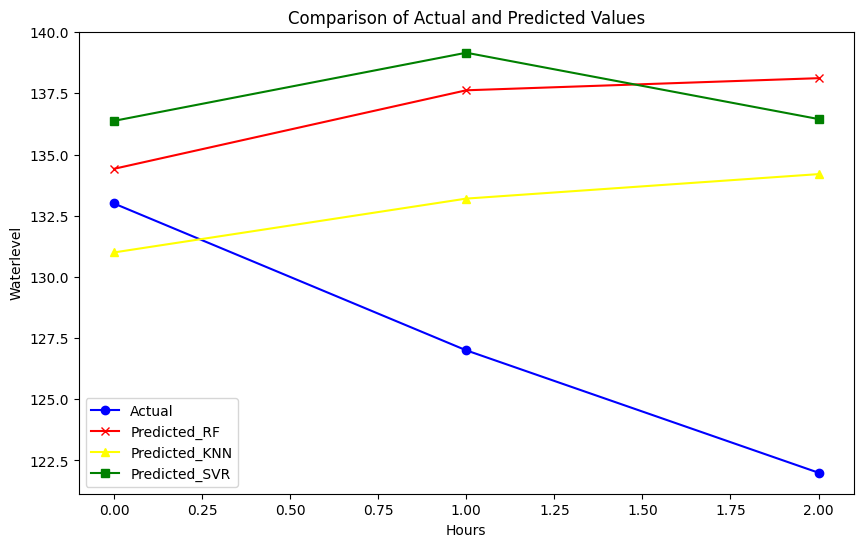

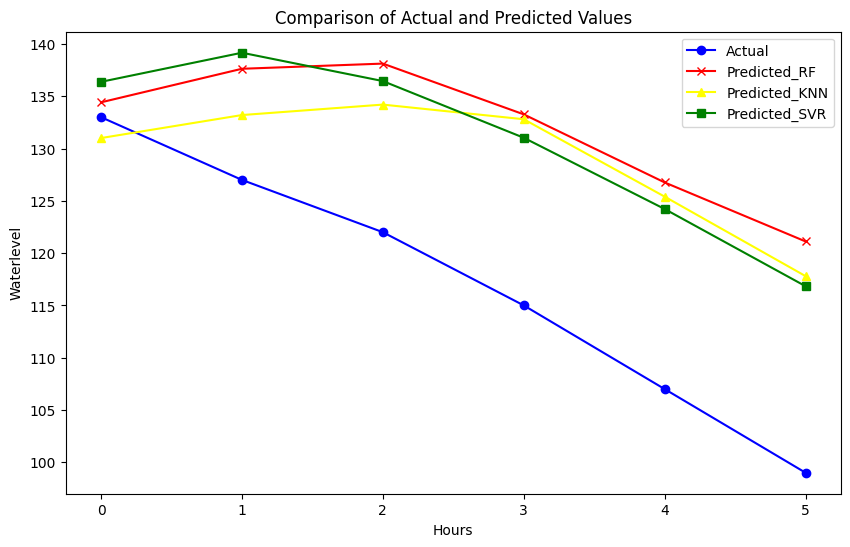

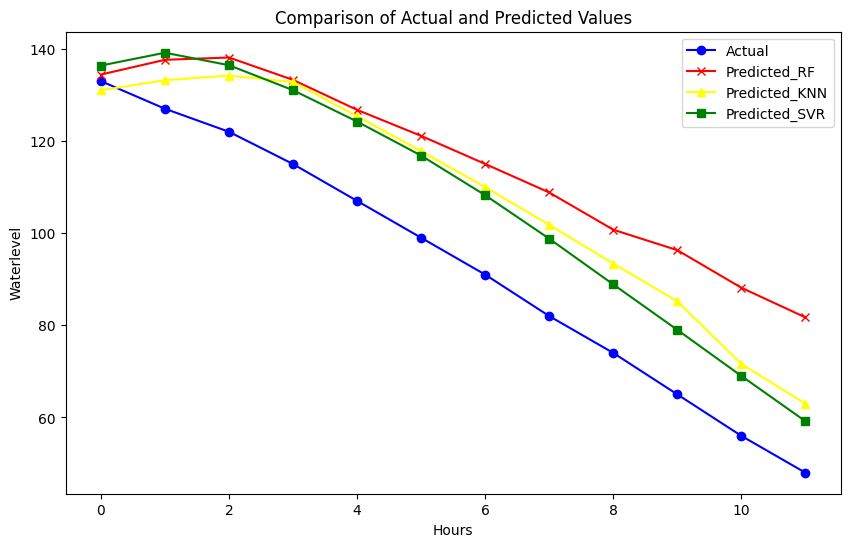

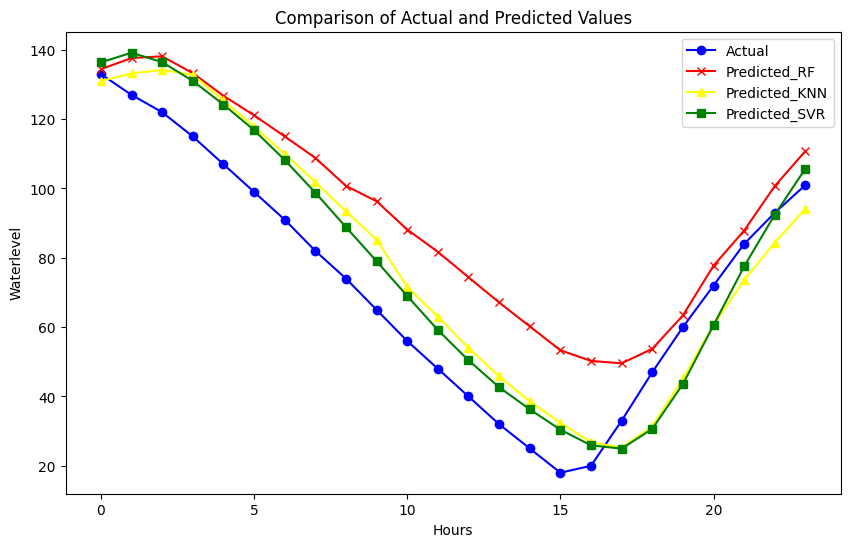

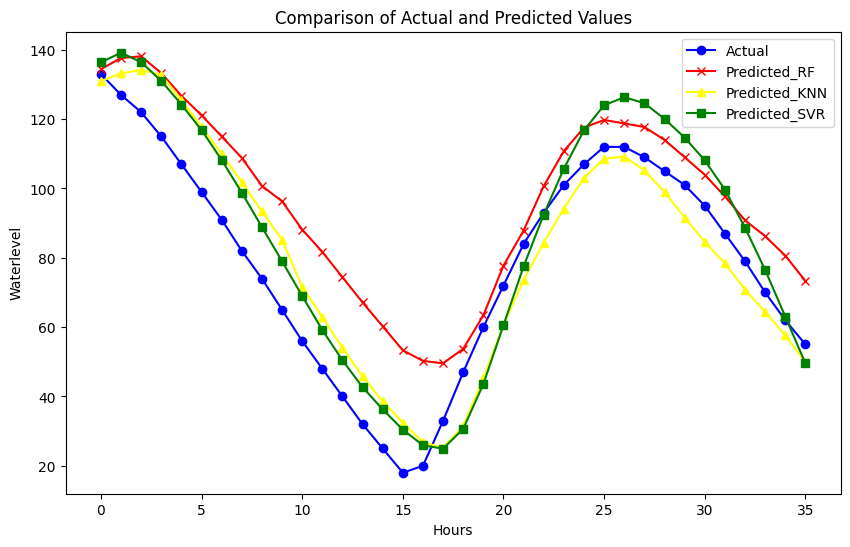

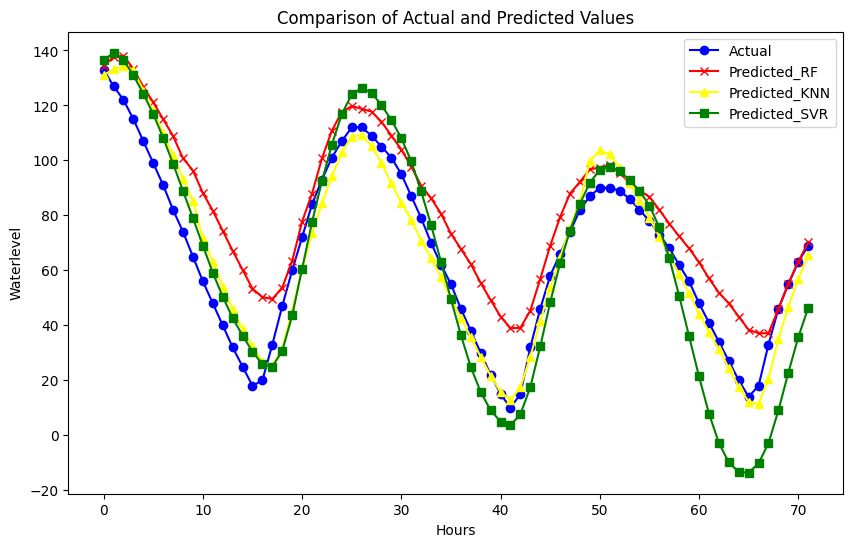

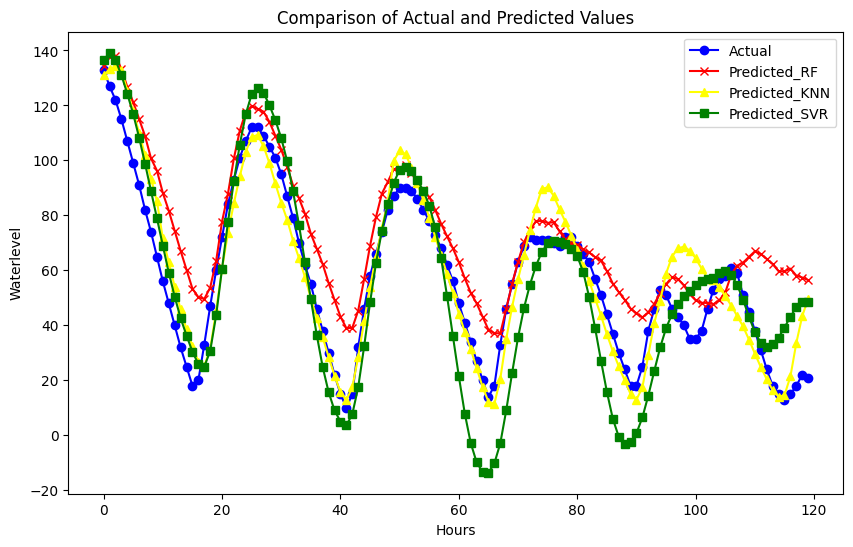

In [ ]:
time_forecast = [3,  6, 12, 24, 36, 72, 120]
for hours in time_forecast:
    plt.figure(figsize=(10, 6))
    
    plt.plot(y_test_original[:hours], label='Actual', color='blue', marker='o')
    plt.plot(predict_RF[:hours], label='Predicted_RF', color='red', marker='x')
    plt.plot(y_test_pred_knn[:hours], label='Predicted_KNN', color='yellow', marker='^')
    plt.plot(y_test_pred[:hours], label='Predicted_SVR', color='green', marker='s')

    plt.title('Comparison of Actual and Predicted Values')
    plt.xlabel('Hours')
    plt.ylabel('Waterlevel')
    plt.legend()

    plt.show()

In [ ]:
models_results = {
    'SVR': metrics_SVR,
    'ARIMA': metrics_ARIMA,
    'KNN': metrics_KNN,
    'RF': metrics_RF
}
models_df = pd.DataFrame.from_dict(models_results, orient='index')

# If you need to reset the index to have it as a column
models_df.reset_index(inplace=True)
models_df.rename(columns={'index': 'Method'}, inplace=True)

In [ ]:
models_df.to_csv('12.csv')